### This code provides supports for results on Distribution of A, including those in Main Text section 2.2 and SI section A.8.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,ListedColormap
import matplotlib.cm as cm
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, shapiro
import seaborn as sns

d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


US distribution of HGH median accratio 

In [2]:
####data source: accratios and census
df_census=pd.read_csv('data/census/all_census_data_with_location.csv',
                     usecols=['census_block_group','population_by_age','percent_above_65'])
dfT=df_census
#homo
for key in ['Health Care Services','Grocery and Food Supply','Housing and Real Estate']:
    df_=pd.read_csv('data/A under 5-mile setting/'+key+'.csv',
                       usecols=['census_block_group','demand_met_in_local'])
    
    df_=df_.rename(columns={'demand_met_in_local':key+'_accratio5m'})
    dfT=pd.merge(dfT,df_)
    
####data source: accratios and census

In [3]:
dfT['census_block_group']=dfT['census_block_group'].astype(str)
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}
dfT['state']=dfT.apply(lambda x: dict_state[str(int(x['census_block_group'][0:2]))] if 
                                       len(x['census_block_group'])==12 else dict_state[str(int(x['census_block_group'][0:1]))],
                                       axis=1)
dfT['age']=dfT.apply(lambda x: 'greater than 0.5' if x['percent_above_65']>0.5 else 'mid',
                             axis=1)
dfT['age']=dfT.apply(lambda x: 'less than 0.2' if x['percent_above_65']<0.2 else x['age'],
                             axis=1)
age_dict={'greater than 0.5':1,'less than 0.2':0,'mid':0.5}

dfT['is_old']=dfT.apply(lambda x: age_dict[x['age']],
                             axis=1)

In [4]:
dfT

,census_block_group,population_by_age,percent_above_65,Health Care Services_accratio5m,Grocery and Food Supply_accratio5m,Housing and Real Estate_accratio5m,state,age,is_old
0,10010201001,745,0.036242,0.574468,0.786667,0.625000,AL,less than 0.2,0.0
1,10010201002,1265,0.114625,0.280000,0.443709,0.286689,AL,less than 0.2,0.0
2,10010202001,960,0.161458,0.655172,0.809524,0.694611,AL,less than 0.2,0.0
3,10010202002,1236,0.094660,0.666667,0.702128,0.741007,AL,less than 0.2,0.0
4,10010203001,2364,0.134095,0.292135,0.696629,0.438953,AL,less than 0.2,0.0
...,...,...,...,...,...,...,...,...,...
220328,721537506011,921,0.226927,0.000000,1.000000,0.615385,PR,mid,0.5
220329,721537506012,2703,0.107658,0.181818,0.666667,0.257143,PR,less than 0.2,0.0
220330,721537506013,1195,0.057741,0.000000,1.000000,0.200000,PR,less than 0.2,0.0
220331,721537506021,2005,0.220449,NaN,NaN,0.277778,PR,mid,0.5


In [5]:
dfS=pd.DataFrame()
dfS['state']=dfT['state'].unique()
dfS['population']=dfS.apply(lambda x:sum(dfT[dfT['state']==x['state']]['population_by_age'] ),axis=1)
dfS['HCS']=dfS.apply(lambda x: np.median(dfT[(dfT['state']==x['state'])&(dfT['Health Care Services_accratio5m']<1.001)].dropna(subset=['Health Care Services_accratio5m'])
                                         ['Health Care Services_accratio5m']),axis=1)
dfS['GFS']=dfS.apply(lambda x: np.median(dfT[(dfT['state']==x['state'])&(dfT['Grocery and Food Supply_accratio5m']<1.001)].dropna(subset=['Grocery and Food Supply_accratio5m'])
                                         ['Grocery and Food Supply_accratio5m']),axis=1)
dfS['HRE']=dfS.apply(lambda x: np.median(dfT[(dfT['state']==x['state'])&(dfT['Housing and Real Estate_accratio5m']<1.001)].dropna(subset=['Housing and Real Estate_accratio5m'])
                                         ['Housing and Real Estate_accratio5m']),axis=1)

dfS['num_old_cbg']=dfS.apply(lambda x: len (dfT[(dfT['state']==x['state'])&(dfT['is_old']==1)]) ,axis=1)



In [6]:
dict_state_posi={ 'AL':(5,6),
                  'AK':(6,1),  
                  'AZ':(4,1),
                  'AR':(4,4), 
                 'CA':(3,0), 
                 'CO':(3,2), 
                 'CT':(2,9), 
                 'DE':(3,9), 
                 'DC':(4,8),
                 'FL':(6,8), 
                 'GA':(5,7), 
                 'HI':(6,0), 
                 'ID':(1,1),
                 'IL':(1,5),
                 'IN':(2,5), 
                 'IA':(2,4), 
                 'KS':(4,3), 
                 'KY':(3,5), 
                 'LA':(5,4), 
                 'ME':(0,10), 
                 'MD':(3,8), 
                 'MA':(1,9), 
                 'MI':(1,6), 
                 'MN':(1,4), 
                 'MS':(5,5), 
                 'MO':(3,4),
                 'MT':(1,2), 
                 'NE':(3,3),
                 'NV':(2,1), 
                 'NH':(0,9),
                 'NJ':(2,8), 
                 'NM':(4,2), 
                 'NY':(1,8),
                 'NC':(4,6),
                 'ND':(1,3), 
                 'OH':(2,6),
                 'OK':(5,3), 
                 'OR':(2,0),
                 'PA':(2,7), 
                 'RI':(2,10), 
                 'SC':(4,7), 
                 'SD':(2,3),
                 'TN':(4,5), 
                 'TX':(6,3),
                 'UT':(3,1), 
                 'VT':(0,8), 
                 'VA':(3,7), 
                 'WA':(1,0), 
                 'WV':(3,6),
                 'WI':(0,5), 
                 'WY':(2,2)}

In [7]:
dfS

,state,population,HCS,GFS,HRE,num_old_cbg
0,AL,4841164,0.236399,0.430556,0.217899,10
1,AK,736855,0.523158,0.561404,0.447368,0
2,AZ,6728577,0.415663,0.620690,0.546548,274
3,AR,2968472,0.250000,0.420807,0.087248,13
4,CA,38654206,0.489362,0.661652,0.542169,221
5,CO,5359295,0.459459,0.618846,0.561404,18
6,CT,3588570,0.478261,0.619048,0.514803,18
7,DE,934695,0.428571,0.537500,0.455702,19
8,DC,659009,0.600000,0.615385,0.327856,0
9,FL,19934451,0.470588,0.627358,0.565789,856


In [ ]:
dfa=dfS.rename(columns={"HCS":"A_HCS","GFS":"A_GFS","HRE":"A_HRE","num_old_cbg":"num_HighAging_cbg"})

C:\Users\Linao\AppData\Local\Temp\ipykernel_18036\2949262187.py:52: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout()
C:\Users\Linao\AppData\Local\Temp\ipykernel_18036\2949262187.py:52: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\Linao\AppData\Local\Temp\ipykernel_18036\2949262187.py:80: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  cbar=fig.colorbar(ax2.imshow([[]],cmap=cmap_for_us_spatial_dis_aaccraatio),ax=ax2,orientation='vertical',norm=norm)


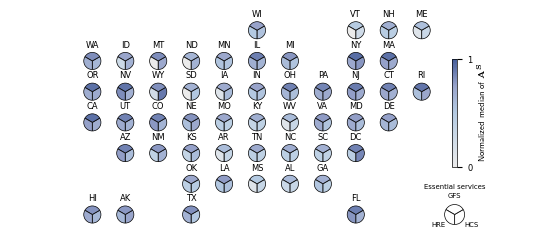

In [133]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

#blues:['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494','#081d58']
colors=['#EBEBEB','#D0DCE8','#B5CBE2','#98A3CA','#455D99']

accmax=max([max(dfS['HCS']),max(dfS['GFS']),max(dfS['HRE'])])
accmin=min([min(dfS['HCS']),min(dfS['GFS']),min(dfS['HRE'])])

popmax=max(dfS['population'])
popmin=min(dfS['population'])


# cmap_for_us_spatial_dis_aaccraatio =ListedColormap(colors)
cmap_for_us_spatial_dis_aaccraatio= plt.cm.colors.LinearSegmentedColormap.from_list('my_cmap', colors,N=100)
norm = plt.Normalize(accmin, accmax)

def value_to_color(value):
    # Clamp value between 0 and 1
    #value = max(0, min(1, value))
    # Get the 'cividis' colormap
    
    
    cmap =cmap_for_us_spatial_dis_aaccraatio  #cm.get_cmap('summer')
    # Map value to colormap
    color = cmap(norm(value))
    return color

def radius(col):
    p=col['population']
    p0=popmin
    p1=popmax
    
    r0=0.4+0.15
    r1=0.9+0.15
    rr=r0+(p-p0)*(r1-r0)/(p1-p0)
    
    p=np.log(col['population'])
    p0=np.log(popmin)
    p1=np.log(popmax)    
    rlog=r0+(p-p0)*(r1-r0)/(p1-p0)
    rconst=0.9
    
    return rconst
    
dfS['radius']=dfS.apply(radius,axis=1)


width_in_inches = 160 * 0.0393701 
height_in_inches =width_in_inches/42*18

fig, ax=plt.subplots(7,12,constrained_layout=True, figsize=(width_in_inches+0.5, height_in_inches))#
fig.tight_layout()
for state in dict_state_posi.keys():
    row=dict_state_posi[state][0]
    col=dict_state_posi[state][1]
    HCS=dfS[dfS['state']==state]['HCS'].iat[0]
    GFS=dfS[dfS['state']==state]['GFS'].iat[0]
    HRE=dfS[dfS['state']==state]['HRE'].iat[0]
    radius=dfS[dfS['state']==state]['radius'].iat[0]

    patches, texts = ax[row][col].pie([1,1,1],colors=[value_to_color(HCS),value_to_color(GFS),value_to_color(HRE)],
                    startangle=-90,radius=radius,explode=[0.01,0.01,0.01],wedgeprops={'linewidth': 0.5, 'edgecolor': 'black'}) 
    #labels=['HCS','GFS','HRE'],
    ax[row][col].set_title(state,fontsize=6,pad=0,color='black')#,fontweight='bold'
    for patch in patches:
        patch.set_edgecolor('black')
#plt.subplots_adjust(wspace=-0.85,hspace=-0.2)
#plt.subplots_adjust(wspace=-0.8,hspace=0.1)
plt.subplots_adjust(wspace=-0.8,hspace=0.3)

for i in range(7):
    for j in range(12):
        ax[i][j].axis('off')


ax2=fig.add_axes([0.52,0.33,0.3,0.4])
#ax2=fig.add_axes([0.58,0.58,0.3,0.4])
ax2.axis('off')

cbar=fig.colorbar(ax2.imshow([[]],cmap=cmap_for_us_spatial_dis_aaccraatio),ax=ax2,orientation='vertical',norm=norm)
cbar.set_ticks([0,1])
cbar.ax.tick_params(labelsize=6) 
cbar.set_label(r'Normalized median of $\mathbf{A^{S}}$',fontsize=6, usetex=True)
cbar.outline.set_linewidth(0.5)

patches, texts=ax[6][11].pie([1,1,1],labels=['HCS','GFS','HRE'],colors=['white','white','white'],
       startangle=-90,radius=0.9+0.15,explode=[0.01,0.01,0.01],labeldistance=1.9,wedgeprops={'linewidth': 0.5},
        textprops = {'fontsize': 5, 'color': 'black'})#,'weight':'bold'
ax[6][11].set_title('Essential services',fontsize=5,pad=10,color='black')#,fontweight='bold'
for patch in patches:
    patch.set_edgecolor('black')

for text in texts:
    text.set_horizontalalignment('center')
    text.set_verticalalignment('center')


#ax[6][11].pie([1],colors=['white'],frame=True,wedgeprops={'edgecolor':'black'},
#        startangle=-90,radius=0.9+0.15,center=(0,0)) 
#ax[6][11].pie([1],colors=['white'],frame=True,wedgeprops={'edgecolor':'black'},startangle=-90,radius=0.65+0.15,center=(0,-0.25)) 
#ax[6][11].pie([1],colors=['white'],frame=True,wedgeprops={'edgecolor':'black'},
#        startangle=-90,radius=0.4+0.15,center=(0,-0.5)) 

#ax[6][11].plot([0,1.5],[0.9+0.15,0.9+0.15],linestyle='--',color='black')
#ax[6][11].plot([0,1.5],[0.4+0.15,0.4+0.15],linestyle='--',color='black')
#ax[6][11].plot([0,1.5],[-0.1+0.15,-0.1+0.15],linestyle='--',color='black')

#ax[6][11].text(1.58,0.9+0.15,r'$\: \mathbf{ 3.9\times {10}^7}$ (CA)',ha='left',fontsize=28,weight='bold', usetex=True)
#ax[6][11].text(1.53,0.4+0.15,r'$\: \mathbf{ (5.8,390)\times{10}^5}$',ha='left',fontsize=28, weight='bold', usetex=True)
#ax[6][11].text(1.58,-0.1+0.15,r' $\:\mathbf{ 5.8\times{10}^5}$ (WY)',ha='left',fontsize=28,weight='bold', usetex=True)

#ax[6][11].set_title('Population',fontsize=30,pad=30,color='black')#,fontweight='bold'



In [ ]:
#fig.savefig('D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/AccRatios/US_A_distribution.svg', format='svg', bbox_inches='tight')

plot correlation between accratio and age

In [10]:
dfT

,census_block_group,population_by_age,percent_above_65,Health Care Services_accratio5m,Grocery and Food Supply_accratio5m,Housing and Real Estate_accratio5m,state,age,is_old
0,10010201001,745,0.036242,0.574468,0.786667,0.625000,AL,less than 0.2,0.0
1,10010201002,1265,0.114625,0.280000,0.443709,0.286689,AL,less than 0.2,0.0
2,10010202001,960,0.161458,0.655172,0.809524,0.694611,AL,less than 0.2,0.0
3,10010202002,1236,0.094660,0.666667,0.702128,0.741007,AL,less than 0.2,0.0
4,10010203001,2364,0.134095,0.292135,0.696629,0.438953,AL,less than 0.2,0.0
...,...,...,...,...,...,...,...,...,...
220328,721537506011,921,0.226927,0.000000,1.000000,0.615385,PR,mid,0.5
220329,721537506012,2703,0.107658,0.181818,0.666667,0.257143,PR,less than 0.2,0.0
220330,721537506013,1195,0.057741,0.000000,1.000000,0.200000,PR,less than 0.2,0.0
220331,721537506021,2005,0.220449,NaN,NaN,0.277778,PR,mid,0.5


In [11]:
df_HCS=dfT[['census_block_group','Health Care Services_accratio5m','state','age','percent_above_65']]
df_HCS=df_HCS.rename(columns={'Health Care Services_accratio5m':'accratio5m'})
df_HCS['type']='Health Care Services'
df_GFS=dfT[['census_block_group','Grocery and Food Supply_accratio5m','state','age','percent_above_65']]
df_GFS=df_GFS.rename(columns={'Grocery and Food Supply_accratio5m':'accratio5m'})
df_GFS['type']='Grocery and Food Supply'
df_HRE=dfT[['census_block_group','Housing and Real Estate_accratio5m','state','age','percent_above_65']]
df_HRE=df_HRE.rename(columns={'Housing and Real Estate_accratio5m':'accratio5m'})
df_HRE['type']='Housing and Real Estate'

dfG=pd.concat([df_HCS,df_GFS,df_HRE])

In [13]:
dffgh=dfG.rename(columns={"accratio5m":"A","age":"age_type","type":"service_type"})

In [12]:
dfG

,census_block_group,accratio5m,state,age,percent_above_65,type
0,10010201001,0.574468,AL,less than 0.2,0.036242,Health Care Services
1,10010201002,0.280000,AL,less than 0.2,0.114625,Health Care Services
2,10010202001,0.655172,AL,less than 0.2,0.161458,Health Care Services
3,10010202002,0.666667,AL,less than 0.2,0.094660,Health Care Services
4,10010203001,0.292135,AL,less than 0.2,0.134095,Health Care Services
...,...,...,...,...,...,...
220328,721537506011,0.615385,PR,mid,0.226927,Housing and Real Estate
220329,721537506012,0.257143,PR,less than 0.2,0.107658,Housing and Real Estate
220330,721537506013,0.200000,PR,less than 0.2,0.057741,Housing and Real Estate
220331,721537506021,0.277778,PR,mid,0.220449,Housing and Real Estate


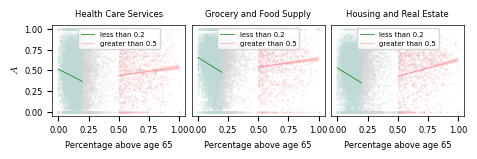

In [56]:
#HGH

import matplotlib.pyplot as plt
import seaborn as sns  

width_in_inches = 135 * 0.0393701 
height_in_inches =width_in_inches/13.5*3

fig, ax=plt.subplots(1,3, figsize=(width_in_inches , height_in_inches))#
fig.subplots_adjust(wspace=0.05)

color_dict={'greater than 0.5':'#EDA1A4','less than 0.2':'#B3D8D5','mid':'lightgray'}

for j,key in enumerate(['Health Care Services','Grocery and Food Supply','Housing and Real Estate']):
    df1=dfG[dfG['type']==key].dropna()


    categories = df1['age'].unique()
    
    if j==0:
        hloc=(0.5,0.6)
    elif j==1:
        hloc=(0.6,0.7)
    else:
        hloc=(0.45,0.65)

    
    # For each category, create a regplot and scatterplot
    for i,category in enumerate(categories):
       
        
        # Subset the data to only this category
        df_subset = df1[df1['age'] == category]
        

        # Sample the subset if it's for scatter points
        df_sample = df_subset.sample(frac=0.05)
        #df_sample1 = df_subset.sample(frac=0.001)
        df_sample2 = df_subset.sample(frac=0.5)

        # Plot the regression line (from the full subset)
        
        
        
        if category=='greater than 0.5':
            
            sn=sns.regplot(data=df_subset , x="percent_above_65", y='accratio5m',scatter=False, ax=ax[j],
                           color=color_dict[category],label=category, scatter_kws={'linewidths': 0.3},ci=95,line_kws={'color': 'red', 'alpha': 0.3,'linewidth': 0.5})
  
            
            # Plot the scatter points (from the sampled subset)
            sn=sns.scatterplot(data=df_sample2, x="percent_above_65", y='accratio5m', 
                        alpha=0.2,color=color_dict[category], ax=ax[j],legend=True,s=2)     
            sn.legend(loc='upper right')
            
        elif category=='less than 0.2':
            sn=sns.regplot(data=df_subset, x="percent_above_65", y='accratio5m',scatter=False, ax=ax[j],
                           color='green',label=category, ci=95,line_kws={'linewidth': 0.5})
           

            # Plot the scatter points (from the sampled subset)
            sn=sns.scatterplot(data=df_sample , x="percent_above_65", y='accratio5m', 
                        color=color_dict[category],alpha=0.2, ax=ax[j],legend=True,s=2)  
            sn.legend(loc='upper right')
            #
        else:
            sn=sns.scatterplot(data=df_sample , x="percent_above_65", y='accratio5m', 
                        color=color_dict[category],alpha=0.2, ax=ax[j],legend=True,s=2) 


    
    for spine in ax[j].spines.values():
            spine.set_linewidth(0.5)  #
            #spine.set_color('gray')

    sn.legend(loc='upper center', fontsize=5)
    sn.set_title(key,fontsize=6)
    if j>0:
        sn.set(ylabel=None)
        sn.tick_params(axis='y', which='both', left=False, labelleft=False, labelsize=6)
    else:
        sn.set_ylabel(r'$A$', fontsize=7, usetex=True)
        sn.tick_params(axis='y', which='both', left=True, labelleft=True, labelsize=6)    
        
    sn.tick_params(axis='x', which='both', bottom=True, left=True, labelsize=6)  
   
    
    sn.set_xlabel('Percentage above age 65', fontsize=6)  
plt.show()      

In [ ]:
#fig.savefig('D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/AccRatios/{}.svg'.format('HGH_A_grouped_age_50_20_green'), format='svg', bbox_inches='tight')

plot US FL AZ CA accratio distributions in two groups

In [15]:
dfT

,census_block_group,population_by_age,percent_above_65,Health Care Services_accratio5m,Grocery and Food Supply_accratio5m,Housing and Real Estate_accratio5m,state,age,is_old
0,10010201001,745,0.036242,0.574468,0.786667,0.625000,AL,less than 0.2,0.0
1,10010201002,1265,0.114625,0.280000,0.443709,0.286689,AL,less than 0.2,0.0
2,10010202001,960,0.161458,0.655172,0.809524,0.694611,AL,less than 0.2,0.0
3,10010202002,1236,0.094660,0.666667,0.702128,0.741007,AL,less than 0.2,0.0
4,10010203001,2364,0.134095,0.292135,0.696629,0.438953,AL,less than 0.2,0.0
...,...,...,...,...,...,...,...,...,...
220328,721537506011,921,0.226927,0.000000,1.000000,0.615385,PR,mid,0.5
220329,721537506012,2703,0.107658,0.181818,0.666667,0.257143,PR,less than 0.2,0.0
220330,721537506013,1195,0.057741,0.000000,1.000000,0.200000,PR,less than 0.2,0.0
220331,721537506021,2005,0.220449,NaN,NaN,0.277778,PR,mid,0.5


t-test

In [58]:

state='FL'
for state in ['FL','AZ','CA']:
    print(state)
    for tp in ['Health Care Services','Grocery and Food Supply','Housing and Real Estate']:
        g2=dfT[(dfT['state']==state)&(dfT['age']=='less than 0.2')&(dfT[tp+'_accratio5m']<1.1)].dropna(subset=[tp+'_accratio5m'])[tp+'_accratio5m']  
        g1=dfT[(dfT['state']==state)&(dfT['age']=='greater than 0.5')&(dfT[tp+'_accratio5m']<1.1)].dropna(subset=[tp+'_accratio5m'])[tp+'_accratio5m']
        t_st,p_va=ttest_ind(g1,g2,equal_var=False)
        print(t_st,p_va)
print('US')
for tp in ['Health Care Services','Grocery and Food Supply','Housing and Real Estate']:
    g2=dfT[(dfT['age']=='less than 0.2')&(dfT[tp+'_accratio5m']<1.1)].dropna(subset=[tp+'_accratio5m'])[tp+'_accratio5m']  
    g1=dfT[(dfT['age']=='greater than 0.5')&(dfT[tp+'_accratio5m']<1.1)].dropna(subset=[tp+'_accratio5m'])[tp+'_accratio5m']
    t_st,p_va=ttest_ind(g1,g2,equal_var=False)
    print(t_st,p_va)

FL
5.69560046423042 1.5987498844764953e-08
4.691354264669087 3.070069959695822e-06
6.191517290492281 8.443232050101185e-10
AZ
0.658678081472946 0.5105856171488727
-1.8769402603446663 0.06146950214070277
0.3544287481487151 0.7232478491794332
CA
-2.00258188615258 0.046463397254962485
-4.154656677346678 4.696968734863297e-05
-1.2557801902545063 0.21051918760105878
US
6.673799018380222 3.107744987757627e-11
3.0819474696367166 0.0020806602014342133
11.592170397940224 2.965083199131744e-30


In [16]:
dfG

,census_block_group,accratio5m,state,age,percent_above_65,type
0,10010201001,0.574468,AL,less than 0.2,0.036242,Health Care Services
1,10010201002,0.280000,AL,less than 0.2,0.114625,Health Care Services
2,10010202001,0.655172,AL,less than 0.2,0.161458,Health Care Services
3,10010202002,0.666667,AL,less than 0.2,0.094660,Health Care Services
4,10010203001,0.292135,AL,less than 0.2,0.134095,Health Care Services
...,...,...,...,...,...,...
220328,721537506011,0.615385,PR,mid,0.226927,Housing and Real Estate
220329,721537506012,0.257143,PR,less than 0.2,0.107658,Housing and Real Estate
220330,721537506013,0.200000,PR,less than 0.2,0.057741,Housing and Real Estate
220331,721537506021,0.277778,PR,mid,0.220449,Housing and Real Estate


In [69]:
trans={"Health Care Services":"HCS","Housing and Real Estate":"HRE","Grocery and Food Supply":"GFS"}
dfG['type']=dfG['type'].apply(lambda x: trans[x])

quartile: 18
quartile 18
quartile 18
quartile 18


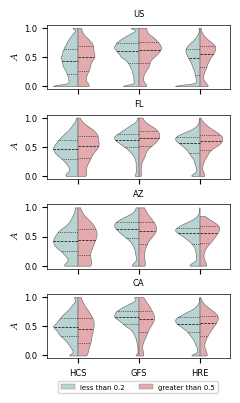

In [122]:
#plot

width_in_inches = 60 * 0.0393701 
height_in_inches =width_in_inches/6*11

fig, ax=plt.subplots(4,1, figsize=(width_in_inches, height_in_inches))#
fig.subplots_adjust(hspace=0.4)

colors={'less than 0.2':'#B3D8D5','greater than 0.5': '#EDA1A4'}

#colors=['#42BCB2', '#197AB7']
#cmap=ListedColormap(colors)

sn=sns.violinplot(x='type',y='accratio5m',hue='age',hue_order=['less than 0.2','greater than 0.5'],
                  data=dfG[dfG['age']!='mid'].dropna(),ax=ax[0],palette=colors,cut=0.0,inner="quartiles",split=True, linewidth=0.5)


quartile_lines = [line for line in ax[0].lines if line.get_linestyle() == '--']


print("quartile:", len(quartile_lines))

for k,line in enumerate(quartile_lines):
    if k%3==1:
        line.set_color('black') 
        line.set_linewidth(0.5)  
        line.set_linestyle('--')  
    else:
        line.set_color('black')  
        line.set_linewidth(0.5)  
        line.set_linestyle(':')  

for spine in ax[0].spines.values():
        spine.set_linewidth(0.5) 

sn.set_title('US',fontsize=6)
sn.set_xlabel('')
sn.set_ylabel(r'$A$', fontsize=7, usetex=True)
ax[0].tick_params(axis='both', which='both', bottom=True, left=True,labelsize=6)  
ax[0].tick_params(axis='x', labelbottom=False)

sn.get_legend().remove()
#sn.legend(title='',fontsize='small',loc='upper right')
for i,state in enumerate(['FL','AZ','CA']):
    plotdata=dfG[(dfG['state']==state)& (dfG['age']!='mid')].dropna()
    sn=sns.violinplot(x='type',y='accratio5m',hue='age',hue_order=['less than 0.2','greater than 0.5'],
                      data=plotdata,ax=ax[i+1],palette=colors,cut=0.0,inner="quartiles",split=True, linewidth=0.5)


   
    quartile_lines = [line for line in ax[i+1].lines if line.get_linestyle() == '--']

   
    print("quartile", len(quartile_lines))
    
    for k,line in enumerate(quartile_lines):
        if k%3==1:
            line.set_color('black')  
            line.set_linewidth(0.5)  
            line.set_linestyle('--') 
        else:
            line.set_color('black')  
            line.set_linewidth(0.5)  
            line.set_linestyle(':')  
    for spine in ax[i + 1].spines.values():
        spine.set_linewidth(0.5) 
        

    sn.set_title(state,fontsize=6)
    sn.set_xlabel('')
    sn.set_ylabel(r'$A$', fontsize=7, usetex=True)
    if i<2:
        sn.get_legend().remove()
        ax[i + 1].tick_params(axis='x', labelbottom=False)
    else:
        sn.legend(title='',ncol=2,loc=(0.06,-0.54),fontsize=5)
        ax[i + 1].tick_params(axis='x', labelbottom=True)

    ax[i+1].tick_params(axis='both', which='both', left=True, labelleft=True, labelsize=6)  

 
        
     


In [ ]:
#fig.savefig('D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/allStatesByParentType/AccRatios/{}.svg'.format('3states_Med_A_grouped_50_20'), format='svg', bbox_inches='tight')

In [9]:
dfa

,state,population,A_HCS,A_GFS,A_HRE,num_HighAging_cbg
0,AL,4841164,0.236399,0.430556,0.217899,10
1,AK,736855,0.523158,0.561404,0.447368,0
2,AZ,6728577,0.415663,0.620690,0.546548,274
3,AR,2968472,0.250000,0.420807,0.087248,13
4,CA,38654206,0.489362,0.661652,0.542169,221
5,CO,5359295,0.459459,0.618846,0.561404,18
6,CT,3588570,0.478261,0.619048,0.514803,18
7,DE,934695,0.428571,0.537500,0.455702,19
8,DC,659009,0.600000,0.615385,0.327856,0
9,FL,19934451,0.470588,0.627358,0.565789,856


In [17]:
dffgh

,census_block_group,A,state,age_type,percent_above_65,service_type
0,10010201001,0.574468,AL,less than 0.2,0.036242,Health Care Services
1,10010201002,0.280000,AL,less than 0.2,0.114625,Health Care Services
2,10010202001,0.655172,AL,less than 0.2,0.161458,Health Care Services
3,10010202002,0.666667,AL,less than 0.2,0.094660,Health Care Services
4,10010203001,0.292135,AL,less than 0.2,0.134095,Health Care Services
...,...,...,...,...,...,...
220328,721537506011,0.615385,PR,mid,0.226927,Housing and Real Estate
220329,721537506012,0.257143,PR,less than 0.2,0.107658,Housing and Real Estate
220330,721537506013,0.200000,PR,less than 0.2,0.057741,Housing and Real Estate
220331,721537506021,0.277778,PR,mid,0.220449,Housing and Real Estate


In [ ]:
#with pd.ExcelWriter('SourceData_Fig3.xlsx') as writer:
#    dfa.to_excel(writer, sheet_name='Fig3a', index=False)
#    dffgh.to_excel(writer, sheet_name='Fig3b-h', index=False)